In [1]:
import numpy as np
import pandas as pd

from embedding import Tokenizer, Word2Vec
from scipy.stats import spearmanr

import matplotlib.pyplot as plt

RAW_DATA = "data/wiki.txt"
WORDSIM_DATA = "data/wordsim353.txt"


In [2]:
!gdown "https://drive.google.com/uc?id=1YnTE3QnU0jI0omV-Bg3OKXs2IWKJ8a34" -O {RAW_DATA}
!gdown "https://drive.google.com/uc?id=1LkcHjUDfOMCgTlOPQ9MWPiH2Nzhp6xMt" -O {WORDSIM_DATA}

Downloading...
From (original): https://drive.google.com/uc?id=1YnTE3QnU0jI0omV-Bg3OKXs2IWKJ8a34
From (redirected): https://drive.google.com/uc?id=1YnTE3QnU0jI0omV-Bg3OKXs2IWKJ8a34&confirm=t&uuid=d187daad-6097-4057-95c7-13349cea8938
To: /Users/dariakay/edu/word2vec/data/wiki.txt
100%|████████████████████████████████████████| 179M/179M [00:05<00:00, 32.1MB/s]
Downloading...
From: https://drive.google.com/uc?id=1LkcHjUDfOMCgTlOPQ9MWPiH2Nzhp6xMt
To: /Users/dariakay/edu/word2vec/data/wordsim353.txt
100%|██████████████████████████████████████| 7.49k/7.49k [00:00<00:00, 10.9MB/s]


In [3]:
wordsim_pairs = pd.read_csv(WORDSIM_DATA)

## Word2Vec Implementation

Here you can find a demonstration of training a word2vec skip-gram version and some analysis of the results. Wikipedia articles are used to train embeddings, evaluation is performed using spearman's correlation on the WordSim353 dataset.

In [4]:
# helper functions

def split_file(input_file, train_filename, val_filename, train_lines_amount):
    with (open(input_file, 'r', encoding='utf-8') as input,
          open(train_filename, 'w', encoding='utf-8') as output_train,
          open(val_filename, 'w', encoding='utf-8') as output_val):
        for i, line in enumerate(input):
            if i < train_lines_amount:
                output_train.write(line)
            else:
                output_val.write(line)

def viz_losses(train_losses, val_losses):
    epochs = range(1, len(train_losses) + 1)
    plt.figure(figsize=(12, 4))
    plt.plot(epochs, train_losses, label="train loss", lw=2, marker='o')
    plt.plot(epochs, val_losses, label="validation loss", lw=2, marker='o')
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title("Training and validation loss")
    plt.legend()
    plt.grid(True)
    plt.show()

def viz_norms(norms_dict: dict, title):
    plt.figure(figsize=(12, 4))
    for param_name in norms_dict.keys():
        plt.plot(range(1, len(norms_dict[param_name]) + 1), norms_dict[param_name], label=param_name)
    plt.xlabel("step")
    plt.ylabel("l2-norm")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

def cosine_similarity(first_embedding, second_embedding):
    return first_embedding @ second_embedding / (np.linalg.norm(first_embedding) * np.linalg.norm(second_embedding))

def evaluate_wordsim(embeddings: np.ndarray, tokenizer: Tokenizer):
    word1_emb = wordsim_pairs["Word 1"].apply(lambda word: embeddings[tokenizer.tokenize(word)]).to_list()
    word2_emb = wordsim_pairs["Word 2"].apply(lambda word: embeddings[tokenizer.tokenize(word)]).to_list()
    cossim = []
    for emb1, emb2 in zip(word1_emb, word2_emb):
        cossim.append(cosine_similarity(emb1, emb2))
    corr, _ = spearmanr(wordsim_pairs["Human (Mean)"].to_numpy(), np.array(cossim))
    return corr

## Training

Let's try to train word2vec with the default optimizer settings (Adam is used):

* lr=0.001
* b1 = 0.9 (the strength of exponential smoothing for the first gradient momentum)
* b2 = 0.999 (the strength of exponential smoothing for the second gradient momentum)

Vocab len: 12035


epoch:   0%|          | 0/7 [00:00<?, ?it/s]

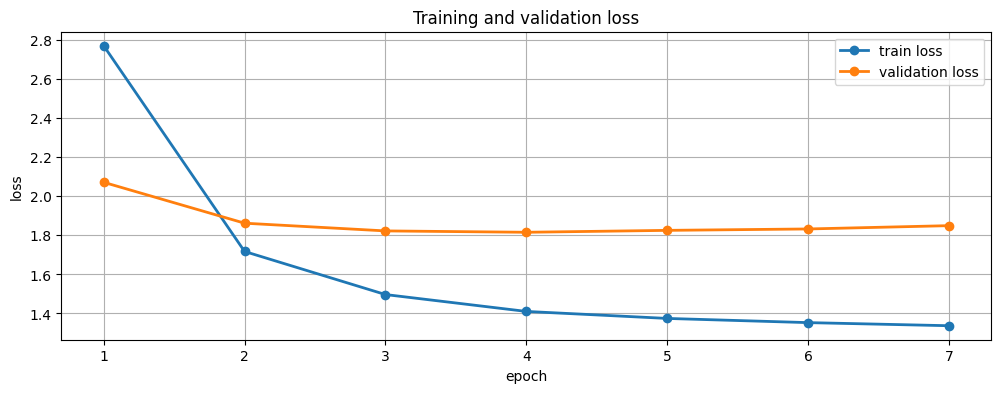

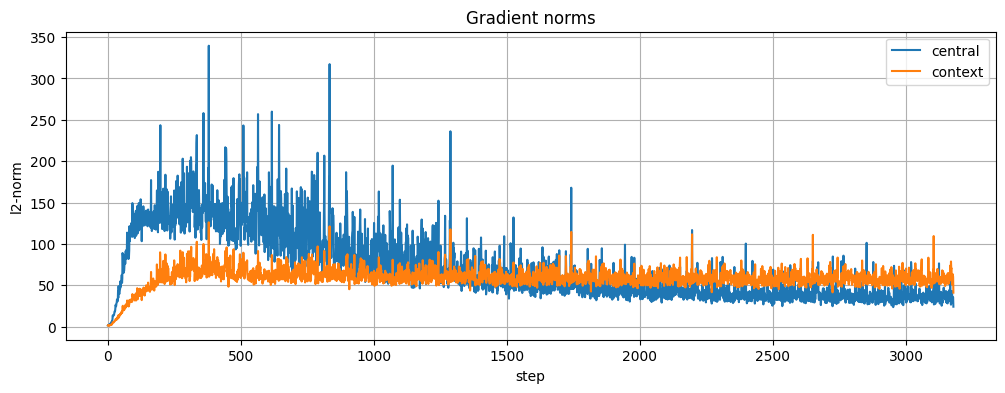

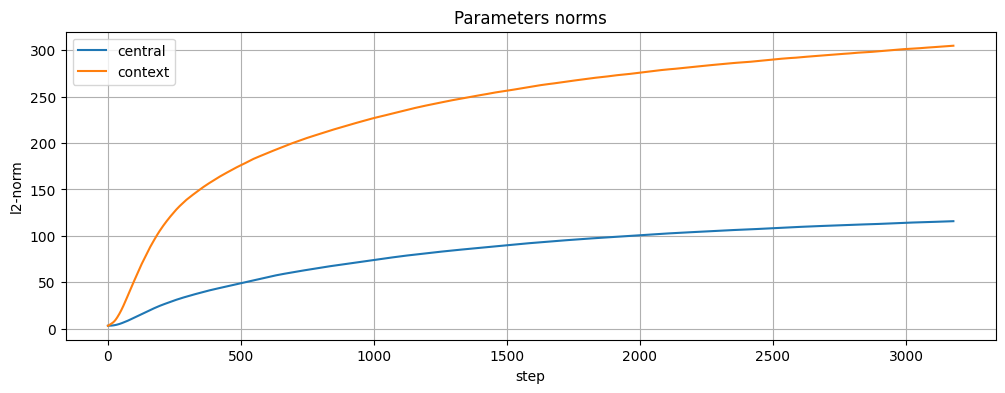

In [5]:
sentences_count = 10_000
train_size = int(0.9 * sentences_count)

processed_data = "data/wiki_dataset_10.txt"
train_data = "data/train_data_10.txt"
val_data = "data/val_data_10.txt"

tokenizer = Tokenizer()
tokenizer.fit(RAW_DATA, processed_data, sentences_count=sentences_count)
split_file(processed_data, train_data, val_data, train_size)

model1 = Word2Vec(train_filename=train_data, val_filename=val_data, embedding_size=100, tokenizer=tokenizer, batch_size=1000)
model1.train(n_iter=7)

viz_losses(model1.train_losses_, model1.val_losses_)
viz_norms(model1.gradient_norms_, "Gradient norms")
viz_norms(model1.parameter_norms_, "Parameters norms")

In [6]:
print(f"Wordsim353 spearman corr: {evaluate_wordsim(model1.model.central_embeddings.weights, tokenizer) :.3f}")

Wordsim353 spearman corr: 0.040


The training process seems ok, but Spearman correlation coefficient is very close to 0 which means that the model didn't learn word similarity. Perhaps this is due to the small amount of training examples. Let's try training on a bigger dataset:

Vocab len: 31005


epoch:   0%|          | 0/7 [00:00<?, ?it/s]

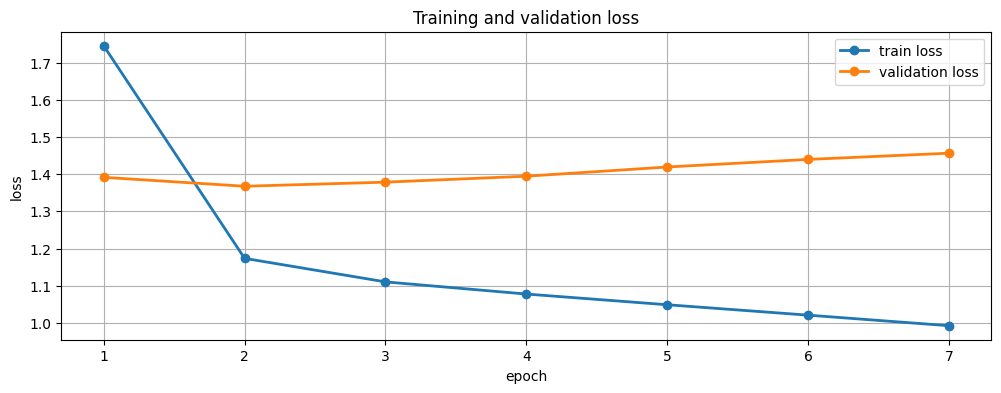

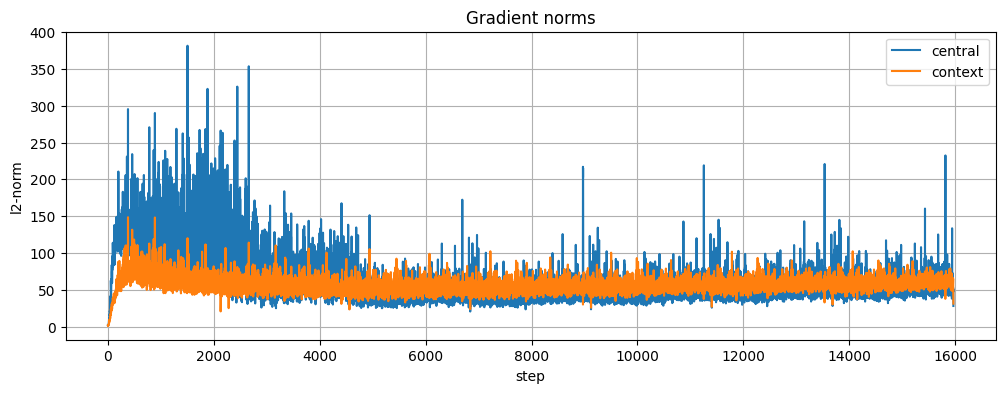

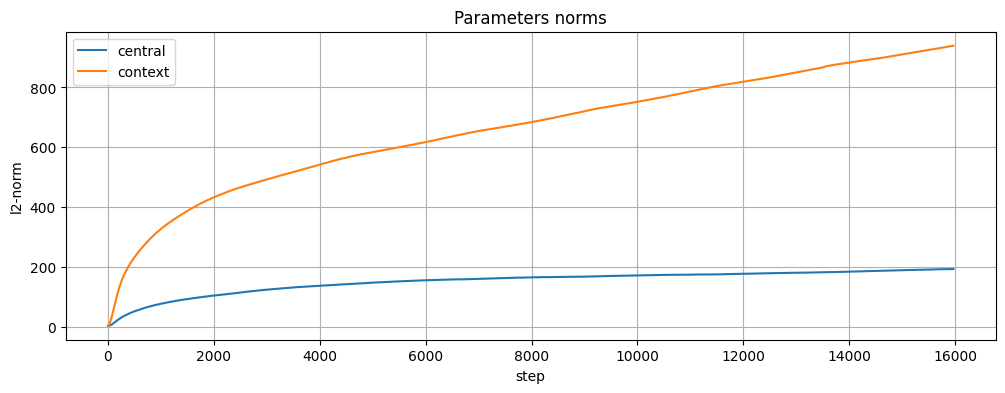

In [7]:
sentences_50 = 50_000
processed_data_50 = "data/wiki_dataset_50.txt"
train_data_50 = "data/train_data_50.txt"
val_data_50 = "data/val_data_50.txt"

tokenizer50 = Tokenizer()
tokenizer50.fit(RAW_DATA, processed_data_50, sentences_count=sentences_50)
split_file(processed_data_50, train_data_50, val_data_50, int(0.9 * sentences_50))

model2 = Word2Vec(train_filename=train_data_50, val_filename=val_data_50, embedding_size=100, tokenizer=tokenizer50, batch_size=1000)
model2.train(n_iter=7)

viz_losses(model2.train_losses_, model2.val_losses_)
viz_norms(model2.gradient_norms_, "Gradient norms")
viz_norms(model2.parameter_norms_, "Parameters norms")

In [8]:
print(f"Wordsim353 spearman corr: {evaluate_wordsim(model2.model.central_embeddings.weights, tokenizer50) :.3f}")

Wordsim353 spearman corr: 0.106


Cosine similarity improved better by 0.05 :) But the model began to overfit on the third iteration.

Another way to improve the quality of embeddings is to increase the number of negative samples used in loss computation. Perhaps k=5 is too small and the training process becomes too noisy.

epoch:   0%|          | 0/7 [00:00<?, ?it/s]

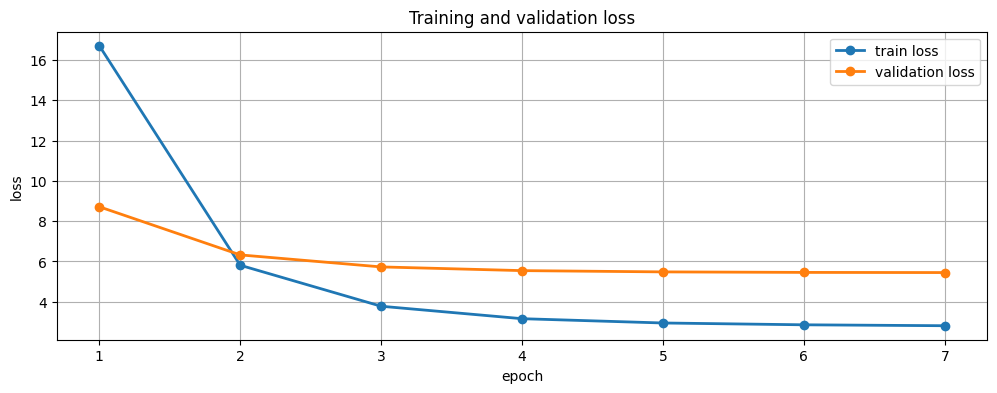

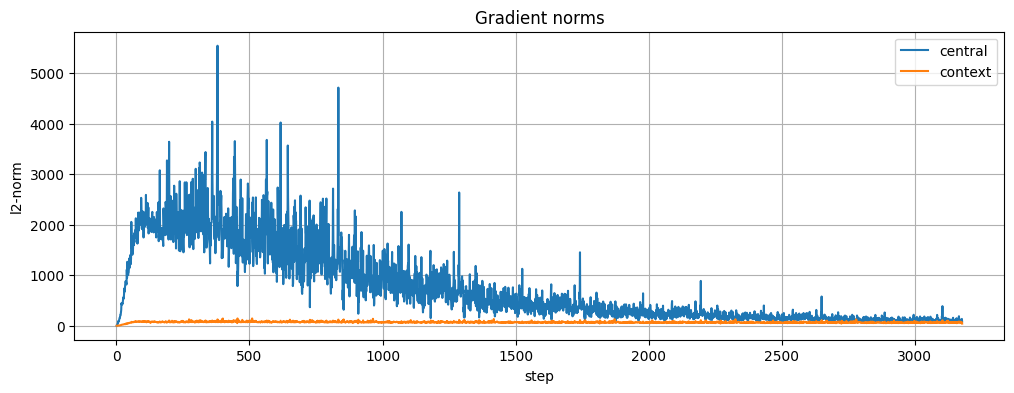

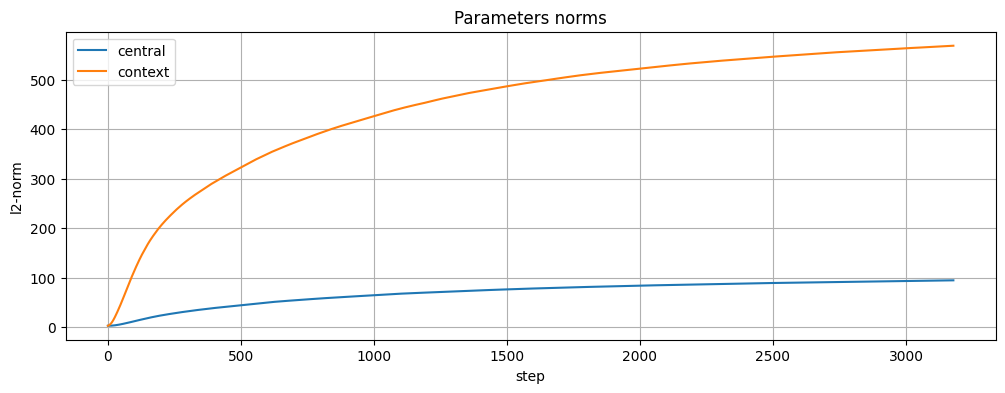

In [9]:
model3 = Word2Vec(
    train_filename=train_data,
    val_filename=val_data,
    embedding_size=100,
    tokenizer=tokenizer,
    batch_size=1000,
    k=50
)
model3.train(n_iter=7)

viz_losses(model3.train_losses_, model3.val_losses_)
viz_norms(model3.gradient_norms_, "Gradient norms")
viz_norms(model3.parameter_norms_, "Parameters norms")

In [10]:
print(f"Wordsim353 spearman corr: {evaluate_wordsim(model3.model.central_embeddings.weights, tokenizer) :.3f}")

Wordsim353 spearman corr: 0.025


Let's combine the two previous approaches:

epoch:   0%|          | 0/5 [00:00<?, ?it/s]

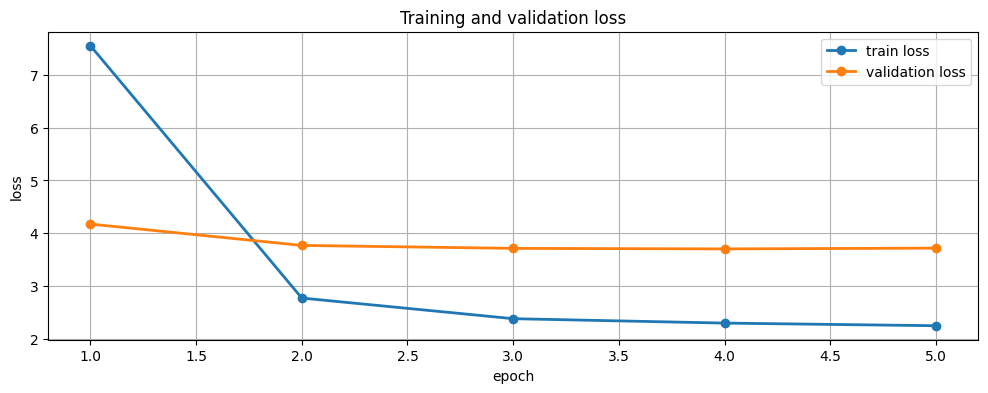

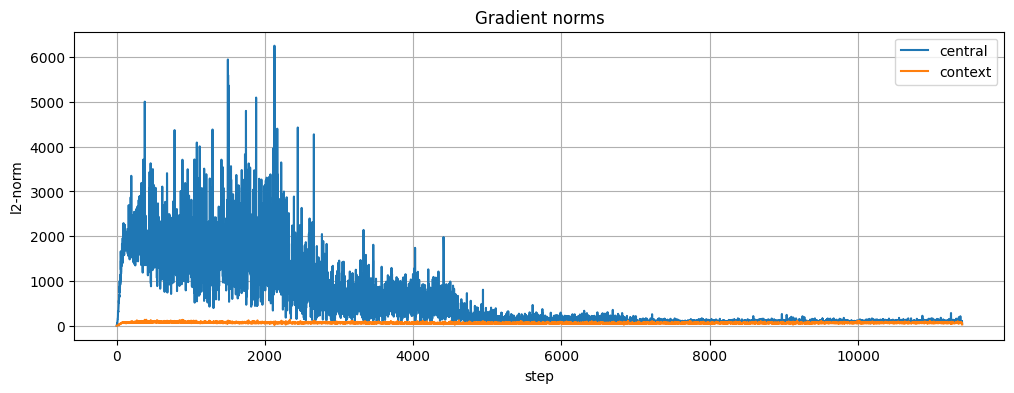

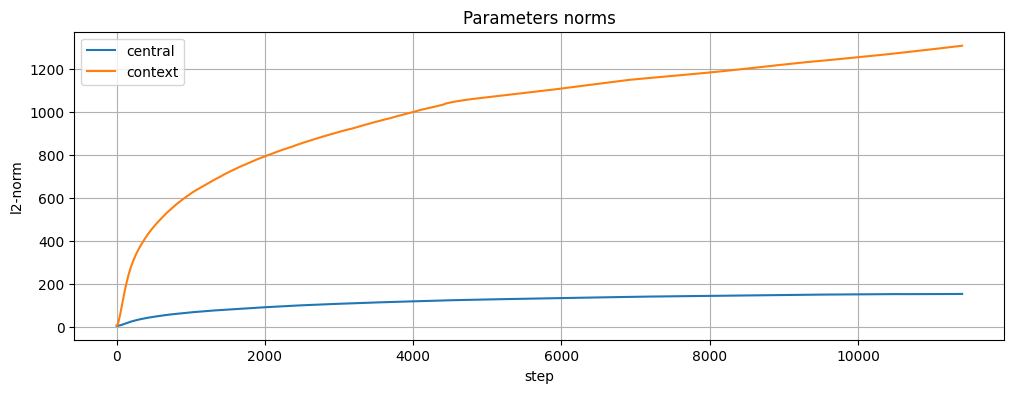

In [11]:
model4 = Word2Vec(
    train_filename=train_data_50,
    val_filename=val_data_50,
    embedding_size=100,
    tokenizer=tokenizer50,
    batch_size=1000,
    k=50
)
model4.train(n_iter=5)

viz_losses(model4.train_losses_, model4.val_losses_)
viz_norms(model4.gradient_norms_, "Gradient norms")
viz_norms(model4.parameter_norms_, "Parameters norms")

In [12]:
print(f"Wordsim353 spearman corr: {evaluate_wordsim(model4.model.central_embeddings.weights, tokenizer50) :.3f}")

Wordsim353 spearman corr: 0.055


Results are not very impressive, because of the small number of positive samples for most of the words from WordSim353, but with better utilisation of the compute capacity word2vec is able to learn word meanings better.

In [18]:
print("people", "children", cosine_similarity(model4.get("people"), model4.get("children")))
print("people", "cats", cosine_similarity(model4.get("people"), model4.get("cats")))
print("children", "cats", cosine_similarity(model4.get("children"), model4.get("cats")))
print("april", "genetic", cosine_similarity(model4.get("april"), model4.get("genetic")))
print("code", "genetic", cosine_similarity(model4.get("code"), model4.get("genetic")))
print("amount", "quantity", cosine_similarity(model4.get("amount"), model4.get("quantity")))

people children 0.7836805325880745
people cats 0.5780516611173485
children cats 0.8787353238602595
april genetic 0.42532495921221547
code genetic 0.9675916671261781
amount quantity 0.7672629359165021
